# Phase III: First ML Proof of Concept (5\%)

### Team Members:
- Rushil Damania
- Sam Gioffre
- Santiago Annunziato

## Data Cleaning

In [1]:
%pip install yfinance
%pip install pytrends

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
from pytrends.request import TrendReq
import time
from datetime import datetime

#to keep track of long loading
def print_progress(message):
    """Print message with timestamp"""
    timestamp = datetime.now().strftime("%H:%M:%S")
    print(f"[{timestamp}] {message}")


print("PHASE III: ML Proof Of Concept")


PHASE III: ML Proof Of Concept


In [2]:
# ===================================
# STEP 1: COLLECT STOCK PRICE DATA
# ===================================
tickers = {
    'JPM': 'Finance - JPMorgan Chase',
    'TSLA': 'Technology - Tesla',
    'TGT': 'Retail - Target'
}


start_date = '2010-01-01'
end_date = '2022-12-31'

stock_data = {}

for ticker, description in tickers.items():
    print_progress(f"  Downloading {description} ({ticker})...")
    start_time = time.time()
    
    stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    elapsed = time.time() - start_time

[20:57:54]   Downloading Finance - JPMorgan Chase (JPM)...


C:\Users\jannu\AppData\Local\Temp\ipykernel_21716\2908934794.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)


[20:57:55]   Downloading Technology - Tesla (TSLA)...
[20:57:55]   Downloading Retail - Target (TGT)...


C:\Users\jannu\AppData\Local\Temp\ipykernel_21716\2908934794.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)
C:\Users\jannu\AppData\Local\Temp\ipykernel_21716\2908934794.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)


In [5]:
# ===================================
# STEP 2: COLLECT GOOGLE TRENDS DATA
# ===================================

print_progress("[STEP 2] Collecting Google Trends Data...")

from pytrends.request import TrendReq
import time

pytrends = TrendReq(hl='en-US', tz=360)

search_terms = {
    'robots': 'Tesla/Technology indicator',
    'back to school': 'Target/Retail indicator',
    'mortgage rates': 'JPMorgan/Finance indicator'
}

trends_data = {}

for i, (term, description) in enumerate(search_terms.items(), 1):
    print_progress(f"  [{i}/{len(search_terms)}] Downloading '{term}' ({description})...")
    pytrends.build_payload([term], timeframe='2010-01-01 2022-12-31')
    trends_data[term] = pytrends.interest_over_time()
    time.sleep(1)  # Brief pause


print(f"\n  Total trends collected: {len(trends_data)}/{len(search_terms)}")

# Display sample if data was collected
if len(trends_data) > 0:
    print("Sample of Google Trends Data:")
    first_term = list(trends_data.keys())[0]
    print(f"\n'{first_term}':")
    print(trends_data[first_term].head(5))


[20:57:57] [STEP 2] Collecting Google Trends Data...
[20:57:57]   [1/3] Downloading 'robots' (Tesla/Technology indicator)...
[20:57:58]   [2/3] Downloading 'back to school' (Target/Retail indicator)...
[20:58:00]   [3/3] Downloading 'mortgage rates' (JPMorgan/Finance indicator)...

  Total trends collected: 3/3
Sample of Google Trends Data:

'robots':
            robots  isPartial
date                         
2010-01-01      38      False
2010-02-01      43      False
2010-03-01      41      False
2010-04-01      39      False
2010-05-01      40      False


In [7]:
# ===================================
# STEP 3: CLEAN STOCK DATA
# ===================================

print_progress("[STEP 3] Cleaning Stock Data")

def clean_stock_data(stock_dict):
    """
    Clean and aggregate stock data to monthly frequency
    
    Cleaning steps:
    - Flatten multi-level columns from yfinance
    - Remove duplicate dates
    - Remove missing values
    - Remove outliers using IQR method
    - Aggregate to monthly frequency
    - Calculate additional features (returns, volatility)
    
    Parameters:
    stock_dict: dictionary of stock dataframes from yfinance
    
    Returns:
    cleaned_dict: dictionary of cleaned monthly stock dataframes
    """
    cleaned_dict = {}
    
    for i, (ticker, df) in enumerate(stock_dict.items(), 1):
        print_progress(f"  [{i}/{len(stock_dict)}] Processing {ticker}...")
        start_time = time.time()
        
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        
        df = df[~df.index.duplicated(keep='first')]
        initial_rows = len(df)
        
        df = df.dropna()
        
        Q1 = df['Close'].quantile(0.25)
        Q3 = df['Close'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df['Close'] >= lower_bound) & (df['Close'] <= upper_bound)]
        
        outliers_removed = initial_rows - len(df)
        
        # Aggregate to monthly (use 'ME' for month-end)
        monthly_df = df.resample('ME').agg({
            'Close': 'last',
            'High': 'max',
            'Low': 'min',
            'Open': 'first',
            'Volume': 'sum'
        })
        
        monthly_df['Return'] = monthly_df['Close'].pct_change() * 100
        monthly_df['Volatility'] = monthly_df['High'] - monthly_df['Low']
        
        monthly_df = monthly_df.dropna()
        
        elapsed = time.time() - start_time
        
        cleaned_dict[ticker] = monthly_df
    
    return cleaned_dict

# Apply cleaning
cleaned_stocks = clean_stock_data(stock_data)

[20:58:03] [STEP 3] Cleaning Stock Data
[20:58:03]   [1/3] Processing JPM...
[20:58:03]   [2/3] Processing TSLA...
[20:58:03]   [3/3] Processing TGT...


C:\Users\jannu\AppData\Local\Temp\ipykernel_21716\1383084500.py:57: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_df['Return'] = monthly_df['Close'].pct_change() * 100


In [9]:
# ===================================
# STEP 4: CLEAN GOOGLE TRENDS DATA
# ===================================

print_progress("[STEP 4] Cleaning Google Trends Data...")

def clean_trends_data(trends_dict):
    """
    Clean Google Trends data to match stock data format
    
    Cleaning steps:
    - Remove 'isPartial' column
    - Ensure proper datetime index
    - Resample to month end to match stock data
    - Remove missing values
    - Rename columns for clarity
    
    Parameters:
    trends_dict: dictionary of trend dataframes from pytrends
    
    Returns:
    cleaned_dict: dictionary of cleaned trend dataframes
    """
    cleaned_dict = {}
    
    for i, (term, df) in enumerate(trends_dict.items(), 1):
        
        if 'isPartial' in df.columns:
            df = df.drop('isPartial', axis=1)
        
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        
        df = df.resample('ME').last()
        
        initial_rows = len(df)
        df = df.dropna()
        removed = initial_rows - len(df)
        
        clean_term = term.replace(' ', '_')
        df.columns = [f'trend_{clean_term}']
        
        cleaned_dict[term] = df
    
    return cleaned_dict

[20:58:04] [STEP 4] Cleaning Google Trends Data...


In [11]:
print_progress("[STEP 5] Merging Stock and Trends Data...")

def merge_all_data(stock_dict, trends_dict):
    """
    Merge all data into single unified DataFrame
    
    Parameters:
    stock_dict: dictionary of cleaned stock dataframes
                (indexed by date, e.g. MonthEnd)
    trends_dict: dictionary of cleaned trend dataframes
                 (indexed by date, same frequency)
    
    Returns:
    merged: single dataframe with all data aligned by date
    """
    merged = pd.DataFrame()

    # 1) Add all stock data (with ticker prefixes)
    for ticker, stock_df in stock_dict.items():

        stock_prefixed = stock_df.add_prefix(f"{ticker}_")
        
        if merged.empty:
            merged = stock_prefixed
        else:
            merged = merged.join(stock_prefixed, how="outer")

    # 2) Add all trends data (with term prefixes)
    for term, trend_df in trends_dict.items():
        clean_term = term.replace(" ", "_")
        
        # Optional: prefix trend columns to avoid collisions
        trend_prefixed = trend_df.add_prefix(f"trend_{clean_term}_")
        
        if merged.empty:
            merged = trend_prefixed
        else:
            merged = merged.join(trend_prefixed, how="outer")

    # 3) Drop incomplete rows
    initial_rows = len(merged)
    merged = merged.dropna()
    removed = initial_rows - len(merged)

    print(f"  Removed {removed} row(s) with incomplete data")
    print(f"  Final dataset: {len(merged)} complete monthly observations")

    # 4) Reset index and standardize date column name
    merged = merged.reset_index()
    if "index" in merged.columns:
        merged = merged.rename(columns={"index": "Date"})
    elif "date" in merged.columns:
        merged = merged.rename(columns={"date": "Date"})

    return merged

# Merge all data
cleaned_trends = clean_trends_data(trends_data)
final_data = merge_all_data(cleaned_stocks, cleaned_trends)


[20:58:06] [STEP 5] Merging Stock and Trends Data...
  Removed 37 row(s) with incomplete data
  Final dataset: 119 complete monthly observations


In [13]:
# Display final merged dataset
if not final_data.empty:
    print("Final Merged Dataset:")
    print(final_data.head(10))
    
    print(f"\nDataset shape: {final_data.shape[0]} rows × {final_data.shape[1]} columns")
    if 'Date' in final_data.columns:
        print(f"Date range: {final_data['Date'].min()} to {final_data['Date'].max()}")
    
    print(f"\nColumns in final dataset:")
    for col in final_data.columns:
        print(f"  - {col}")

Final Merged Dataset:
        Date  JPM_Close   JPM_High    JPM_Low   JPM_Open   JPM_Volume  \
0 2010-07-31  26.906446  27.547715  23.486361  24.408181  832405700.0   
1 2010-08-31  24.287952  27.854987  23.746875  27.374037  723429400.0   
2 2010-09-30  25.423519  27.721382  24.488337  24.541777  717143800.0   
3 2010-10-31  25.168711  27.235454  24.218949  25.610553  949249000.0   
4 2010-11-30  25.014881  27.650131  24.633627  25.155328  760406300.0   
5 2010-12-31  28.372488  28.840680  25.182092  25.382746  665999200.0   
6 2011-01-31  30.092516  30.762125  28.559092  28.760415  827482200.0   
7 2011-02-28  31.264336  32.382608  29.663948  30.266613  597586300.0   
8 2011-03-31  30.869255  31.538880  29.061301  31.117023  684643600.0   
9 2011-04-30  30.720245  32.181174  29.306432  31.170590  577996200.0   

   JPM_Return  JPM_Volatility  TSLA_Close  TSLA_High  ...  TGT_Close  \
0   10.175055        4.061354    1.329333   1.728000  ...  33.250813   
1   -9.731846        4.108112 

## Part 3: Visualizations

In [16]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

### Visualization 1: Correlation Heatmap

In [18]:
### Visualization 2: Scatter Plots with Linear Regression

#### Part 1
(3%) The implementation (using NumPy) of your first ML model as a function call to the cleaned data

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import probplot, shapiro
import numpy as np

In [24]:
# -----------------------------------------
# STEP A: Prepare Data for ML
# -----------------------------------------

# Rename columns
final_data = final_data.rename(columns={
    'trend_robots_trend_robots': 'trend_robots',
    'trend_back_to_school_trend_back_to_school': 'trend_back_to_school',
    'trend_mortgage_rates_trend_mortgage_rates': 'trend_mortgage_rates'
})

# Select modeling dataframe
ml_df = final_data[['Date',
                    'JPM_Return', 'TSLA_Return', 'TGT_Return',
                    'trend_robots', 'trend_back_to_school', 'trend_mortgage_rates'
                   ]]

# Drop any missing values (should be none)
ml_df = ml_df.dropna()

print(ml_df.head())


        Date  JPM_Return  TSLA_Return  TGT_Return  trend_robots  \
0 2010-07-31   10.175055   -16.324005    4.372596            34   
1 2010-08-31   -9.731846    -2.306871    0.179980            34   
2 2010-09-30    4.675432     4.774129    4.456569            36   
3 2010-10-31   -1.002255     7.006342   -2.806856            36   
4 2010-11-30   -0.611194    61.767386   10.138380            37   

   trend_back_to_school  trend_mortgage_rates  
0                    31                    30  
1                    70                    33  
2                    31                    26  
3                     9                    26  
4                     8                    27  


In [58]:
#using sklearn (in addition to NumPy)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import probplot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model(X, y, title):
    """
    Fit a linear regression model and check assumptions with diagnostic plots.
    """
    X = np.array(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=3
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{title}")
    print(f"  MSE: {mse:.3f}")
    print(f"  R²:  {r2:.4f}")

    residuals = y_test - y_pred

    # ---- Plots ----
    plt.figure(figsize=(16, 12))

    # 1. Residuals vs Fitted
    plt.subplot(2,2,1)
    sns.scatterplot(x=y_pred, y=residuals)
    plt.title('Residuals vs Fitted')

    # 2. Residuals vs Order
    plt.subplot(2,2,2)
    plt.scatter(range(len(residuals)), residuals)
    plt.title('Residuals vs Order')

    # 3. Q-Q Plot
    plt.subplot(2,2,3)
    probplot(residuals, dist='norm', plot=plt)
    plt.title('Normal Q-Q')

    # 4. Histogram
    plt.subplot(2,2,4)
    plt.hist(residuals, bins=25, alpha=0.6)
    plt.title('Histogram of Residuals')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    return model, mse, r2



TSLA Return with Google Trends (Robots)
  MSE: 451.398
  R²:  -0.0100


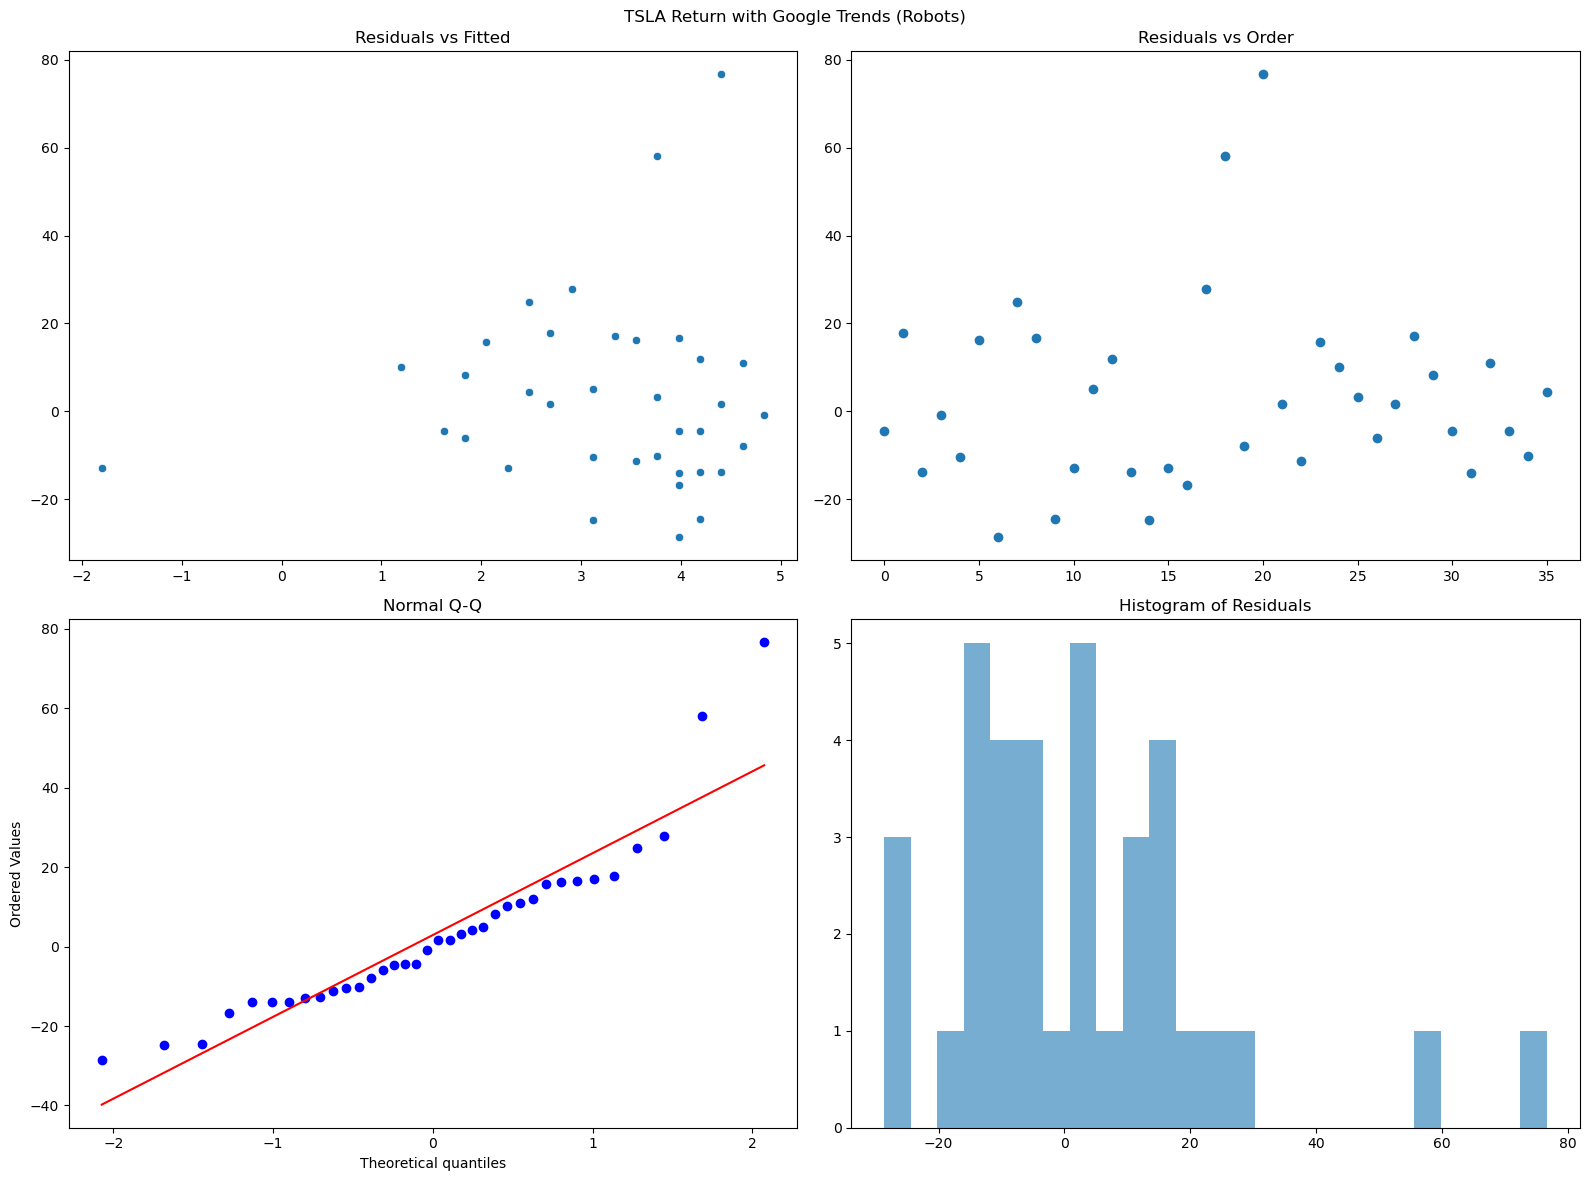

In [60]:
# -----------------------------------------
# MODEL 1: Linear Regression
# -----------------------------------------

X = ml_df['trend_robots']
y = ml_df['TSLA_Return']

model_tsla, mse, r2 = evaluate_model(
    X, y, "TSLA Return with Google Trends (Robots)"
)


In [30]:
#functions for NumPy linear regression
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot

def numpy_linear_regression(X, y):
    """
    NumPy implementation of linear regression using the normal equation.
    
    Args:
        X: array-like, shape (n_samples,) or (n_samples, n_features)
        y: array-like, shape (n_samples,)
        
    Returns:
        w: weight vector including intercept, shape (n_features + 1,)
    """
    
    X = np.asarray(X)
    y = np.asarray(y)
    
    # Make sure X is 2D
    if X.ndim == 1:
        X = X.reshape(-1, 1)
        
    n = X.shape[0]
    
    # Add bias term (intercept)
    X_bias = np.column_stack([np.ones(n), X])
    

    XtX = X_bias.T @ X_bias
    XtX_inv = np.linalg.inv(XtX)
    w = XtX_inv @ X_bias.T @ y
    
    return w

def predict_lr(X, w):
    """
    Make predictions using weights from numpy_linear_regression.
    """
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    n = X.shape[0]
    X_bias = np.column_stack([np.ones(n), X])
    return X_bias @ w


Weights (intercept, slope): [13.92254455 -0.24817085]
Mean Squared Error (MSE): 275.167
R-squared (R2): 0.0129


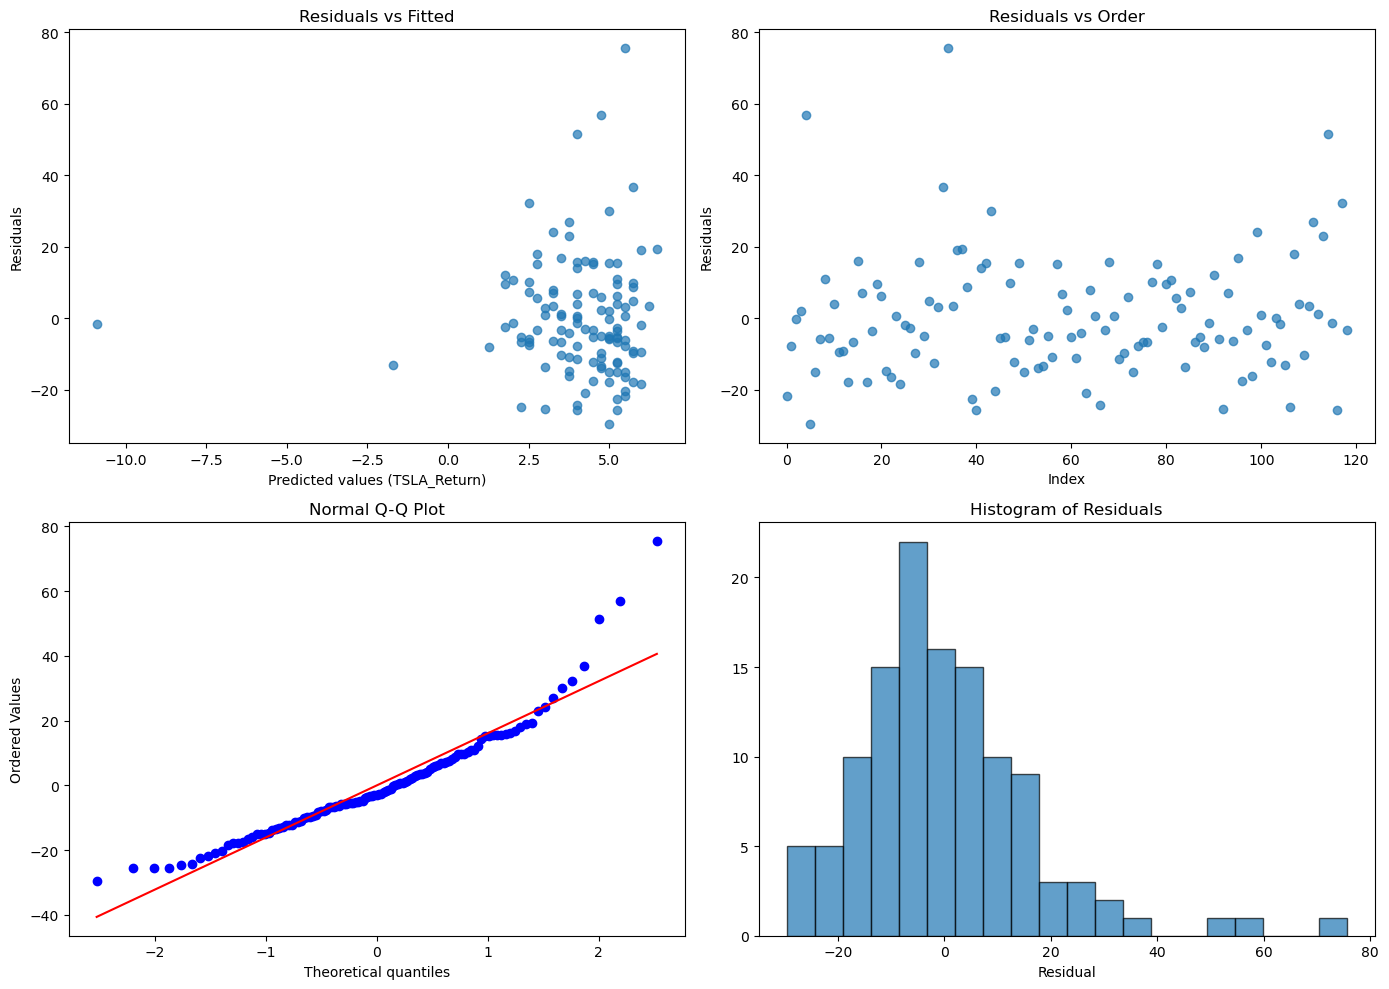

In [52]:
# Extract X and y
X = ml_df['trend_robots'].to_numpy()
y = ml_df['TSLA_Return'].to_numpy()

# Fit the NumPy linear regression model
w = numpy_linear_regression(X, y)
print("Weights (intercept, slope):", w)

# Predictions
y_pred = predict_lr(X, w)

# Metrics
mse = np.mean((y - y_pred) ** 2)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"R-squared (R2): {r2:.4f}")

residuals = y - y_pred

# 1. Residuals vs fitted
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.7)
plt.xlabel("Predicted values (TSLA_Return)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

# 2. Residuals vs order (index)
plt.subplot(2, 2, 2)
plt.scatter(np.arange(len(residuals)), residuals, alpha=0.7)
plt.xlabel("Index")
plt.ylabel("Residuals")
plt.title("Residuals vs Order")

# 3. Q-Q plot
plt.subplot(2, 2, 3)
probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")

# 4. Histogram of residuals
plt.subplot(2, 2, 4)
plt.hist(residuals, bins=20, alpha=0.7, edgecolor='black')
plt.xlabel("Residual")
plt.title("Histogram of Residuals")

plt.tight_layout()
plt.show()


Weights (intercept, slope): [ 5.09143297 -0.19859312]
Mean Squared Error (MSE): 49.313
R-squared (R2): 0.0648


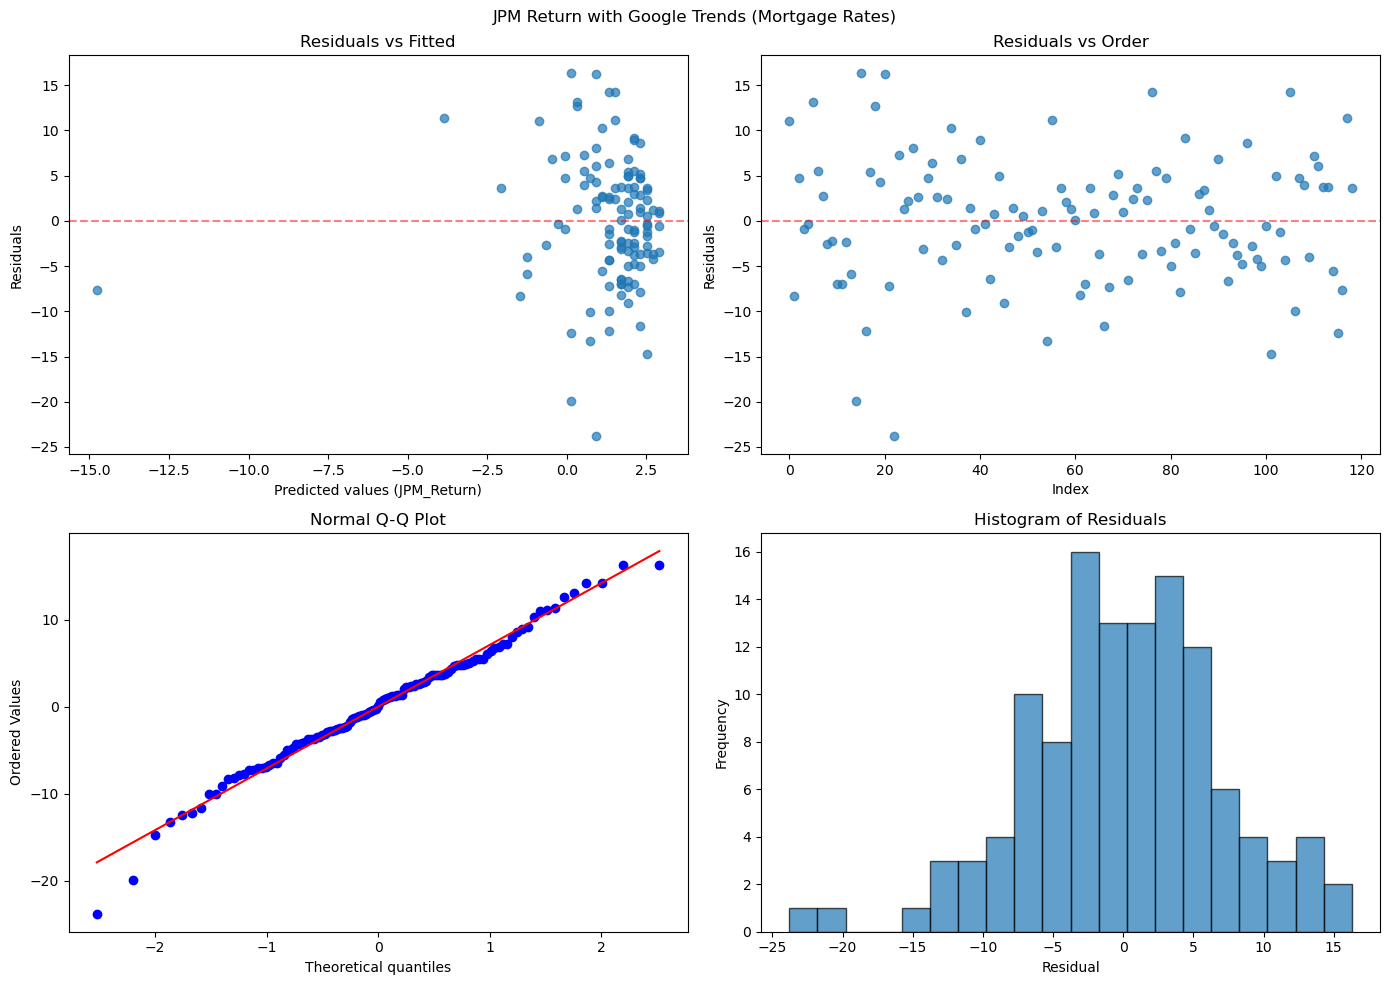

In [54]:
# -----------------------------------------
# MODEL 2: JPM Return with Google Trends (Mortgage Rates)
# -----------------------------------------

X_jpm = ml_df['trend_mortgage_rates'].to_numpy()
y_jpm = ml_df['JPM_Return'].to_numpy()

# Fit the NumPy linear regression model
w_jpm = numpy_linear_regression(X_jpm, y_jpm)
print("Weights (intercept, slope):", w_jpm)

# Predictions
y_pred_jpm = predict_lr(X_jpm, w_jpm)

# Metrics
mse_jpm = np.mean((y_jpm - y_pred_jpm) ** 2)
ss_res_jpm = np.sum((y_jpm - y_pred_jpm) ** 2)
ss_tot_jpm = np.sum((y_jpm - np.mean(y_jpm)) ** 2)
r2_jpm = 1 - ss_res_jpm / ss_tot_jpm

print(f"Mean Squared Error (MSE): {mse_jpm:.3f}")
print(f"R-squared (R2): {r2_jpm:.4f}")

# Diagnostic Plots
residuals_jpm = y_jpm - y_pred_jpm

plt.figure(figsize=(14, 10))

# 1. Residuals vs fitted
plt.subplot(2, 2, 1)
plt.scatter(y_pred_jpm, residuals_jpm, alpha=0.7)
plt.xlabel("Predicted values (JPM_Return)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 2. Residuals vs order (index)
plt.subplot(2, 2, 2)
plt.scatter(np.arange(len(residuals_jpm)), residuals_jpm, alpha=0.7)
plt.xlabel("Index")
plt.ylabel("Residuals")
plt.title("Residuals vs Order")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 3. Q-Q plot
plt.subplot(2, 2, 3)
probplot(residuals_jpm, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")

# 4. Histogram of residuals
plt.subplot(2, 2, 4)
plt.hist(residuals_jpm, bins=20, alpha=0.7, edgecolor='black')
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

plt.suptitle("JPM Return with Google Trends (Mortgage Rates)")
plt.tight_layout()
plt.show()

Weights (intercept, slope): [0.58587064 0.02820346]
Mean Squared Error (MSE): 47.765
R-squared (R2): 0.0077


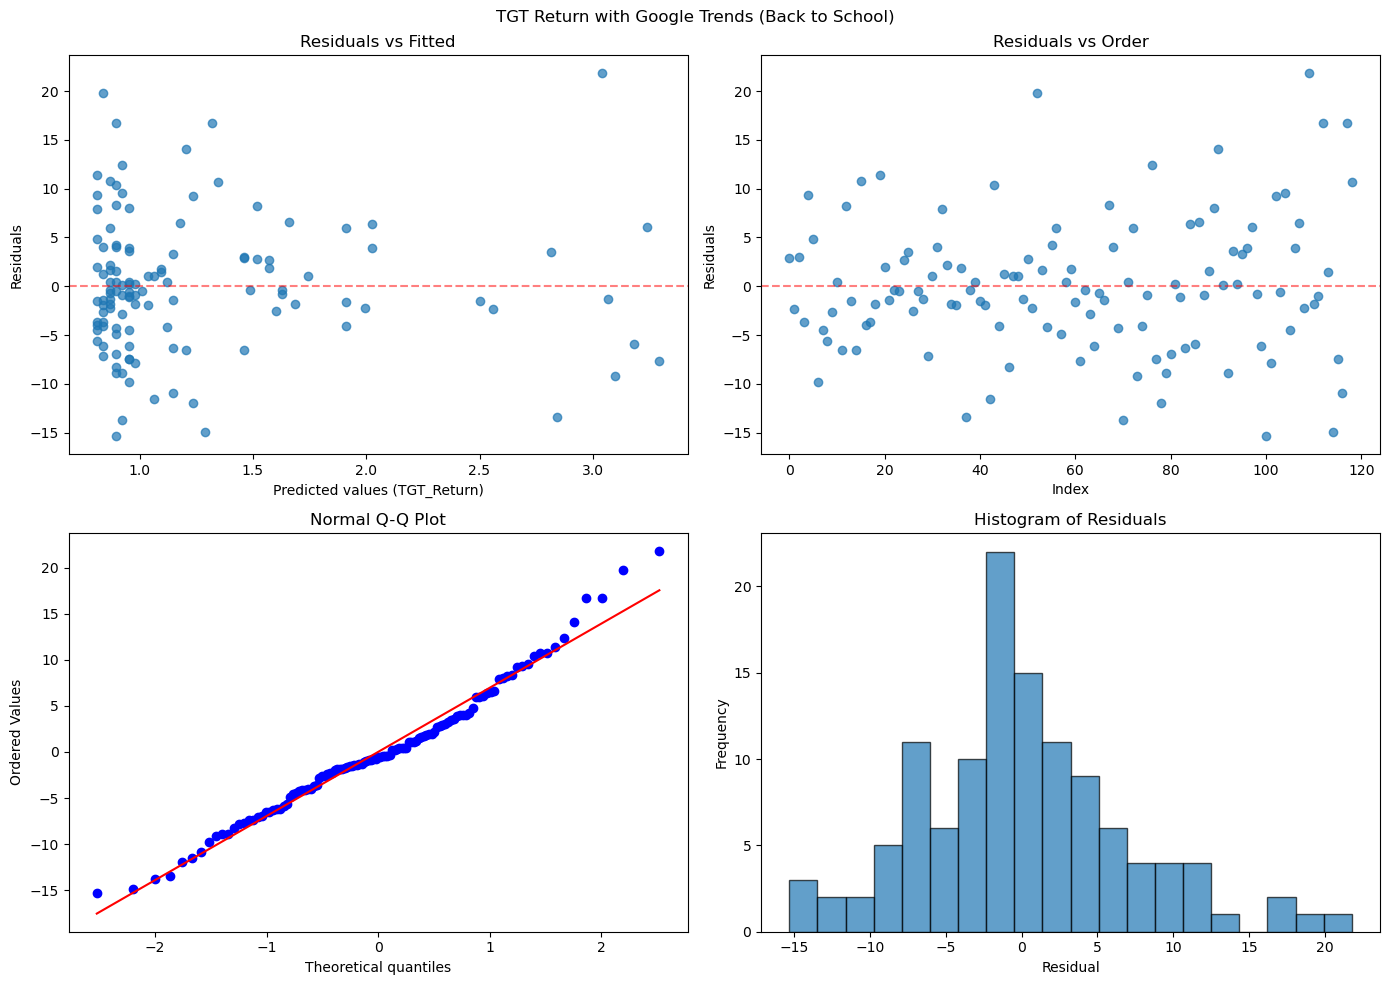

In [56]:
# -----------------------------------------
# MODEL 3: TGT Return with Google Trends (Back to School)
# -----------------------------------------

X_tgt = ml_df['trend_back_to_school'].to_numpy()
y_tgt = ml_df['TGT_Return'].to_numpy()

# Fit the NumPy linear regression model
w_tgt = numpy_linear_regression(X_tgt, y_tgt)
print("Weights (intercept, slope):", w_tgt)

# Predictions
y_pred_tgt = predict_lr(X_tgt, w_tgt)

# Metrics
mse_tgt = np.mean((y_tgt - y_pred_tgt) ** 2)
ss_res_tgt = np.sum((y_tgt - y_pred_tgt) ** 2)
ss_tot_tgt = np.sum((y_tgt - np.mean(y_tgt)) ** 2)
r2_tgt = 1 - ss_res_tgt / ss_tot_tgt

print(f"Mean Squared Error (MSE): {mse_tgt:.3f}")
print(f"R-squared (R2): {r2_tgt:.4f}")

# Diagnostic Plots
residuals_tgt = y_tgt - y_pred_tgt

plt.figure(figsize=(14, 10))

# 1. Residuals vs fitted
plt.subplot(2, 2, 1)
plt.scatter(y_pred_tgt, residuals_tgt, alpha=0.7)
plt.xlabel("Predicted values (TGT_Return)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 2. Residuals vs order (index)
plt.subplot(2, 2, 2)
plt.scatter(np.arange(len(residuals_tgt)), residuals_tgt, alpha=0.7)
plt.xlabel("Index")
plt.ylabel("Residuals")
plt.title("Residuals vs Order")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 3. Q-Q plot
plt.subplot(2, 2, 3)
probplot(residuals_tgt, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")

# 4. Histogram of residuals
plt.subplot(2, 2, 4)
plt.hist(residuals_tgt, bins=20, alpha=0.7, edgecolor='black')
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

plt.suptitle("TGT Return with Google Trends (Back to School)")
plt.tight_layout()
plt.show()